# 07 · Clinical Interpretation
## NHANES 2017–March 2020 Women's CKM Phenotyping Project

---

**Author:** Alexandra Velez, MD  
**Inputs:**  
  `data/processed/cluster_assignments.csv` — 1,266 women, k=3 labels  
  `data/processed/clustering_prescale.csv` — unscaled preprocessed values  
  `data/processed/outlier_phenotype.csv` — 19 extreme outlier women  
  `data/processed/apo_unknown.csv` — 89 unknown APO status  
**Last updated:** 2026

---

### What this notebook does

The clustering is done. This notebook asks whether it means anything.

Three phenotypes emerged from the k=3 solution — a metabolic risk group 
with elevated HbA1c, BMI, and glucose enriched for GDM history, and two 
lower-risk groups that differ more in degree than in kind. Whether those 
phenotypes are clinically coherent, whether the GDM enrichment is more 
than coincidence, and whether the findings hold up under scrutiny — that 
is the work here.

The notebook also characterizes two groups that sat outside the primary 
analysis: 19 women with severely uncontrolled diabetes whose extreme 
biomarker values dominated k-selection metrics, and 89 ever-pregnant 
women whose APO status could not be determined. Both groups deserve 
attention — exclusion from clustering does not mean exclusion from the 
clinical story.

### The central question

> Among reproductive-age women aged 20–44, do those with adverse pregnancy 
> outcomes — particularly gestational diabetes — already show distinct early 
> cardiometabolic biomarker profiles compared to women without APOs?

The short answer, previewed here: yes, with important nuance about what 
"distinct" means when clusters overlap and risk exists on a continuum.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, chi2_contingency
import warnings

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
CLUSTER_PATH   = Path('../data/processed/cluster_assignments.csv')
PRESCALE_PATH  = Path('../data/processed/clustering_prescale.csv')
OUTLIER_PATH   = Path('../data/processed/outlier_phenotype.csv')
APO_UNK_PATH   = Path('../data/processed/apo_unknown.csv')
RAW_PATH       = Path('../data/processed/ckm_features.csv')
FIG_DIR        = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

# ── Feature sets ───────────────────────────────────────────────────────────
CLUSTERING_FEATURES = [
    'Age_Menarche', 'Parity', 'Pregnancy_Loss', 'APO_Score',
    'HbA1c', 'BMI', 'Mean_SBP', 'eGFR', 'HDL', 'Glucose',
]

CKM_BIOMARKERS = ['HbA1c', 'BMI', 'Waist', 'Mean_SBP', 'Mean_DBP',
                  'eGFR', 'HDL', 'Glucose']

REPRO_FEATURES = ['Age_Menarche', 'Parity', 'Pregnancy_Loss',
                  'APO_Score', 'Has_GDM', 'Has_Macrosomia',
                  'Nulliparous', 'Ever_Pregnant']

MED_FLAGS = ['On_Metformin', 'On_Statin', 'On_Antihypertensive',
             'On_Insulin', 'On_Hormonal_Contraception', 'Any_Prescription']

DEMO_VARS = ['RIDAGEYR', 'RIDRETH3', 'INDFMPIR', 'DMDEDUC2']

# ── Cluster labels and colors ──────────────────────────────────────────────
CLUSTER_NAMES = {
    0: 'Metabolic Risk',
    1: 'Low Risk',
    2: 'Lowest Risk',
}

CLUSTER_COLORS = {
    0: '#D55E00',   # vermillion — metabolic risk
    1: '#0072B2',   # blue — low risk
    2: '#009E73',   # green — lowest risk
}

# Okabe-Ito for APO subgroups — consistent with prior notebooks
APO_COLORS = {
    'never_preg': '#999999',
    'no_apo':     '#0072B2',
    'macs_only':  '#56B4E9',
    'gdm_only':   '#E69F00',
    'gdm_macs':   '#D55E00',
}

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Setup complete.')
print(f'  Cluster assignments: {CLUSTER_PATH}')
print(f'  Pre-scale matrix:    {PRESCALE_PATH}')
print(f'  Outlier phenotype:   {OUTLIER_PATH}')
print(f'  APO unknown:         {APO_UNK_PATH}')

Setup complete.
  Cluster assignments: ../data/processed/cluster_assignments.csv
  Pre-scale matrix:    ../data/processed/clustering_prescale.csv
  Outlier phenotype:   ../data/processed/outlier_phenotype.csv
  APO unknown:         ../data/processed/apo_unknown.csv


---
## Section 2 · Load & Validate

In [2]:
# ── Load cluster assignments ───────────────────────────────────────────────
df = pd.read_csv(CLUSTER_PATH, index_col='SEQN')

assert df.shape == (1266, 27), \
    f'Unexpected shape {df.shape} — expected (1266, 27)'
assert df['Cluster'].nunique() == 3, \
    'Expected 3 clusters'
assert df['Cluster_Label'].nunique() == 3, \
    'Expected 3 cluster labels'

print(f'✓ Cluster assignments loaded: {df.shape}')

# ── Load pre-scale matrix ──────────────────────────────────────────────────
df_pre = pd.read_csv(PRESCALE_PATH, index_col='SEQN')

print(f'✓ Pre-scale matrix loaded: {df_pre.shape}')

# ── Load raw CKM features for variables not in clustering matrix ───────────
df_raw = pd.read_csv(RAW_PATH, index_col='SEQN')

print(f'✓ Raw CKM features loaded: {df_raw.shape}')

# ── Load outlier phenotype ─────────────────────────────────────────────────
df_out = pd.read_csv(OUTLIER_PATH, index_col='SEQN')

assert df_out.shape[0] == 19, \
    f'Unexpected outlier count: {df_out.shape[0]}'

print(f'✓ Outlier phenotype loaded: {df_out.shape}')

# ── Load APO unknown group ─────────────────────────────────────────────────
df_apo_unk = pd.read_csv(APO_UNK_PATH, index_col='SEQN')

assert df_apo_unk.shape[0] == 89, \
    f'Unexpected APO unknown count: {df_apo_unk.shape[0]}'

print(f'✓ APO unknown group loaded: {df_apo_unk.shape}')

# ── Merge pre-scale biomarkers onto cluster assignments ────────────────────
# df has scaled features — need original units for clinical interpretation
# Merge unscaled values from df_pre and df_raw

# Unscaled clustering features from df_pre
for feat in CLUSTERING_FEATURES:
    if feat in df_pre.columns:
        df[f'{feat}_raw'] = df_pre.loc[df.index, feat]

# Additional descriptive variables from df_raw
additional = ['Has_GDM', 'Has_Macrosomia', 'Waist', 'Mean_DBP',
              'Gravidity', 'Irregular_Periods', 'WTSAFPRP',
              'Triglycerides', 'LDL']
for var in additional:
    if var in df_raw.columns:
        df[f'{var}_raw'] = df_raw.loc[df.index, var]

print(f'\n✓ Unscaled values merged onto cluster dataframe')
print(f'  Final shape: {df.shape}')

# ── Cluster distribution summary ───────────────────────────────────────────
print(f'\nCluster distribution:')
print(f'  {"Label":<20} {"N":>6} {"% of sample":>12}')
print(f'  {"─"*20} {"─"*6} {"─"*12}')

for cluster, label in CLUSTER_NAMES.items():
    n   = (df['Cluster'] == cluster).sum()
    pct = n / len(df) * 100
    print(f'  {label:<20} {n:>6,} {pct:>11.1f}%')

print(f'  {"─"*20} {"─"*6} {"─"*12}')
print(f'  {"Total":<20} {len(df):>6,} {"100.0%":>12}')

# ── All assertions passed ──────────────────────────────────────────────────
print(f'\n✓ All assertions passed — ready for clinical interpretation')

✓ Cluster assignments loaded: (1266, 27)
✓ Pre-scale matrix loaded: (1512, 59)
✓ Raw CKM features loaded: (1603, 59)
✓ Outlier phenotype loaded: (19, 25)
✓ APO unknown group loaded: (89, 59)

✓ Unscaled values merged onto cluster dataframe
  Final shape: (1266, 46)

Cluster distribution:
  Label                     N  % of sample
  ──────────────────── ────── ────────────
  Metabolic Risk          243        19.2%
  Low Risk                273        21.6%
  Lowest Risk             750        59.2%
  ──────────────────── ────── ────────────
  Total                 1,266       100.0%

✓ All assertions passed — ready for clinical interpretation


---
## Section 3 · Cluster Phenotype Profiles

The three clusters identified in notebook 06 are characterized here in 
original clinical units. Scaled features were useful for clustering — 
they are not useful for interpretation. A woman with a scaled HbA1c of 
1.405 means nothing; a mean HbA1c of 6.8% in a reproductive-age cohort 
means she is at the diagnostic threshold for diabetes.

Statistical comparisons use Kruskal-Wallis for continuous variables — 
appropriate for non-normal distributions without assuming equal variances 
— and chi-square for categorical variables. P-values are reported for 
orientation, not as the primary basis for interpretation. With n=1,266 
and meaningful group sizes, even small differences will reach significance; 
effect size and clinical magnitude matter more.

In [3]:
# ── Cluster phenotype summary table ───────────────────────────────────────
from scipy.stats import kruskal, chi2_contingency

def kruskal_p(df, feature, cluster_col='Cluster'):
    """Kruskal-Wallis p-value across clusters for a continuous feature."""
    groups = [df.loc[df[cluster_col] == c, feature].dropna().values
              for c in sorted(df[cluster_col].unique())]
    if any(len(g) == 0 for g in groups):
        return np.nan
    try:
        _, p = kruskal(*groups)
        return p
    except Exception:
        return np.nan

def chi2_p(df, feature, cluster_col='Cluster'):
    """Chi-square p-value across clusters for a binary feature."""
    ct = pd.crosstab(df[cluster_col], df[feature])
    if ct.shape[1] < 2:
        return np.nan
    try:
        _, p, _, _ = chi2_contingency(ct)
        return p
    except Exception:
        return np.nan

def fmt_p(p):
    if np.isnan(p):
        return '—'
    if p < 0.001:
        return '<0.001'
    return f'{p:.3f}'

# ── Build summary ──────────────────────────────────────────────────────────
clusters     = [0, 1, 2]
cluster_ns   = {c: (df['Cluster'] == c).sum() for c in clusters}
rows         = []

# ── CKM Biomarkers ─────────────────────────────────────────────────────────
biomarker_config = [
    ('HbA1c_raw',    'HbA1c (%)',              'continuous'),
    ('Glucose_raw',  'Glucose (mg/dL)',         'continuous'),
    ('BMI_raw',      'BMI (kg/m²)',             'continuous'),
    ('Waist_raw',    'Waist circumference (cm)','continuous'),
    ('Mean_SBP_raw', 'Systolic BP (mmHg)',      'continuous'),
    ('Mean_DBP_raw', 'Diastolic BP (mmHg)',     'continuous'),
    ('eGFR_raw',     'eGFR (mL/min/1.73m²)',   'continuous'),
    ('HDL_raw',      'HDL cholesterol (mg/dL)', 'continuous'),
]

rows.append(('── CKM Biomarkers ──', '', '', '', ''))
for feat, label, _ in biomarker_config:
    if feat not in df.columns:
        continue
    p = kruskal_p(df, feat)
    row = [label]
    for c in clusters:
        vals = df.loc[df['Cluster'] == c, feat].dropna()
        row.append(f'{vals.median():.1f} [{vals.quantile(0.25):.1f}–{vals.quantile(0.75):.1f}]')
    row.append(fmt_p(p))
    rows.append(tuple(row))

# ── Reproductive Features ──────────────────────────────────────────────────
rows.append(('── Reproductive History ──', '', '', '', ''))

repro_continuous = [
    ('Age_Menarche_raw', 'Age at menarche (years)', 'continuous'),
    ('Parity_raw',       'Parity',                  'continuous'),
    ('Pregnancy_Loss_raw','Pregnancy losses',        'continuous'),
    ('APO_Score_raw',    'APO Score',                'continuous'),
]

for feat, label, _ in repro_continuous:
    if feat not in df.columns:
        continue
    p = kruskal_p(df, feat)
    row = [label]
    for c in clusters:
        vals = df.loc[df['Cluster'] == c, feat].dropna()
        row.append(f'{vals.median():.1f} [{vals.quantile(0.25):.1f}–{vals.quantile(0.75):.1f}]')
    row.append(fmt_p(p))
    rows.append(tuple(row))

repro_binary = [
    ('Ever_Pregnant',  'Ever pregnant (%)'),
    ('Nulliparous',    'Nulliparous (%)'),
    ('Has_GDM_raw',    'GDM history (%)'),
    ('Has_Macrosomia_raw', 'Macrosomia history (%)'),
]

for feat, label in repro_binary:
    col = feat if feat in df.columns else f'{feat}'
    if col not in df.columns:
        continue
    p = chi2_p(df, col)
    row = [label]
    for c in clusters:
        mask = df['Cluster'] == c
        n_c  = mask.sum()
        n_yes = df.loc[mask, col].sum()
        row.append(f'{n_yes/n_c*100:.1f}%')
    row.append(fmt_p(p))
    rows.append(tuple(row))

# ── Medication Flags ───────────────────────────────────────────────────────
rows.append(('── Medication Prevalence ──', '', '', '', ''))

med_config = [
    ('On_Metformin',              'Metformin (%)'),
    ('On_Statin',                 'Statin (%)'),
    ('On_Antihypertensive',       'Antihypertensive (%)'),
    ('On_Insulin',                'Insulin (%)'),
    ('On_Hormonal_Contraception', 'Hormonal contraception (%)'),
    ('Any_Prescription',          'Any CKM medication (%)'),
]

for feat, label in med_config:
    if feat not in df.columns:
        continue
    p = chi2_p(df, feat)
    row = [label]
    for c in clusters:
        mask  = df['Cluster'] == c
        n_c   = mask.sum()
        n_yes = df.loc[mask, feat].sum()
        row.append(f'{n_yes/n_c*100:.1f}%')
    row.append(fmt_p(p))
    rows.append(tuple(row))

# ── Demographics ───────────────────────────────────────────────────────────
rows.append(('── Demographics ──', '', '', '', ''))

demo_continuous = [
    ('RIDAGEYR', 'Age (years)', 'continuous'),
    ('INDFMPIR', 'Income-to-poverty ratio', 'continuous'),
]

for feat, label, _ in demo_continuous:
    if feat not in df.columns:
        continue
    p = kruskal_p(df, feat)
    row = [label]
    for c in clusters:
        vals = df.loc[df['Cluster'] == c, feat].dropna()
        row.append(f'{vals.median():.1f} [{vals.quantile(0.25):.1f}–{vals.quantile(0.75):.1f}]')
    row.append(fmt_p(p))
    rows.append(tuple(row))

# ── Build dataframe ────────────────────────────────────────────────────────
col_names = ['Feature',
             f'Metabolic Risk\n(n={cluster_ns[0]})',
             f'Low Risk\n(n={cluster_ns[1]})',
             f'Lowest Risk\n(n={cluster_ns[2]})',
             'p-value']

df_summary = pd.DataFrame(rows, columns=col_names)

# ── Print summary table ────────────────────────────────────────────────────
print('═'*95)
print('CLUSTER PHENOTYPE SUMMARY TABLE')
print('Continuous variables: median [IQR]   |   Binary variables: %')
print('P-values: Kruskal-Wallis (continuous), Chi-square (binary)')
print('═'*95)
print(f'\n  {"Feature":<35} '
      f'{"Metabolic Risk":>18} '
      f'{"Low Risk":>18} '
      f'{"Lowest Risk":>18} '
      f'{"p":>8}')
print(f'  {"":.<35} '
      f'{"(n=243)":>18} '
      f'{"(n=273)":>18} '
      f'{"(n=750)":>18} '
      f'{"":>8}')
print(f'  {"─"*35} {"─"*18} {"─"*18} {"─"*18} {"─"*8}')

for row in rows:
    if row[1] == '':
        print(f'\n  {row[0]}')
    else:
        print(f'  {row[0]:<35} '
              f'{row[1]:>18} '
              f'{row[2]:>18} '
              f'{row[3]:>18} '
              f'{row[4]:>8}')

print(f'\n{"═"*95}')

# ── Export summary table ───────────────────────────────────────────────────
SUMMARY_PATH = Path('../data/processed/cluster_summary_table.csv')
df_summary.to_csv(SUMMARY_PATH, index=False)
print(f'\n✓ Summary table exported: {SUMMARY_PATH}')

═══════════════════════════════════════════════════════════════════════════════════════════════
CLUSTER PHENOTYPE SUMMARY TABLE
Continuous variables: median [IQR]   |   Binary variables: %
P-values: Kruskal-Wallis (continuous), Chi-square (binary)
═══════════════════════════════════════════════════════════════════════════════════════════════

  Feature                                 Metabolic Risk           Low Risk        Lowest Risk        p
  ...................................            (n=243)            (n=273)            (n=750)         
  ─────────────────────────────────── ────────────────── ────────────────── ────────────────── ────────

  ── CKM Biomarkers ──
  HbA1c (%)                                5.8 [5.6–6.0]      5.3 [5.1–5.5]      5.2 [5.0–5.4]   <0.001
  Glucose (mg/dL)                      99.0 [92.0–107.0]   87.0 [82.0–91.0]   86.0 [81.0–91.0]   <0.001
  BMI (kg/m²)                           36.5 [31.6–43.1]   25.5 [21.6–31.0]   27.7 [22.9–32.9]   <0.001
  Waist

### What the table shows

The metabolic risk cluster is not a statistical artifact. Its biomarker 
profile is clinically coherent across every domain — and the consistency 
is what makes it compelling.

**CKM biomarkers:**
Median HbA1c of 5.8% sits at the prediabetes threshold. Median fasting 
glucose of 99 mg/dL approaches impaired fasting glucose. Median BMI of 
36.5 kg/m² is class II obesity — not marginally elevated, substantially 
elevated. Waist circumference of 113 cm exceeds the metabolic syndrome 
threshold for women (88 cm) by 25 cm. HDL of 46 mg/dL falls below the 
protective threshold of 50 mg/dL. Every single metabolic marker moves 
in the same direction, and every difference is significant at p<0.001.

eGFR is the notable exception — nearly identical across all three clusters 
(110–115 mL/min/1.73m²). This is not a surprise. Kidney function decline 
in CKM disease takes decades; at ages 20–44, even women with significant 
metabolic dysregulation have largely preserved glomerular filtration. The 
kidney signal, if it exists in this cohort, will appear later.

**Reproductive history:**
GDM history is 15.6% in the metabolic risk cluster versus 6.7–8.1% in 
the low-risk groups — more than double. Macrosomia history follows the 
same pattern (16.0% vs 5.5–13.2%). Ever-pregnant women are 
overrepresented in the metabolic risk cluster (80.2% vs 66–69%), 
consistent with the known bidirectional relationship between pregnancy 
and cardiometabolic risk.

Pregnancy_Loss is the one variable that does not differentiate clusters 
(p=0.065) — the medians are identical at 0.0 across all three groups. 
This feature was included in the clustering set based on its theoretical 
relevance to vascular and inflammatory risk, but the data does not support 
a strong independent signal here. Worth noting honestly rather than 
glossing over.

One finding that deserves its own paragraph: age at menarche. The Low 
Risk cluster shows a median of 15.0 years versus 12.0 in both the 
Metabolic Risk and Lowest Risk clusters. That three-year difference is 
striking and was not anticipated. Earlier menarche is a known risk factor 
for insulin resistance, obesity, and cardiovascular disease — so the 
Metabolic Risk cluster's earlier menarche (median 12.0) is directionally 
consistent. But why the Low Risk cluster also shows late menarche while 
having near-normal biomarkers is an interesting question this cross-sectional 
data cannot fully answer. It may reflect a genuinely different hormonal 
developmental trajectory, or it may be a feature of the cluster's 
demographic composition. Something to flag rather than over-interpret.

**Medications:**
The metabolic risk cluster carries the heaviest medication burden where 
it matters most — metformin at 7.4% versus 1.1% in both other clusters, 
antihypertensives at 17.3% versus 4–5%, insulin at 1.6% versus 0–0.4%. 
These women are already being treated, which means their biomarker values 
likely underestimate the true underlying disease burden. A HbA1c of 5.8% 
on metformin is not the same as a HbA1c of 5.8% without it.

Hormonal contraception runs in the opposite direction — 4.9% in the 
metabolic risk cluster versus 12–13% elsewhere. Clinically expected: 
women with significant cardiometabolic disease are more likely to have 
contraindications to or concerns about hormonal methods.

**Demographics:**
The metabolic risk cluster is older — median 36 versus 30–32 years. 
This is expected and important to hold in mind during interpretation. 
Some of the biomarker elevation reflects age-related accumulation of 
risk rather than purely APO-mediated pathways. The cross-sectional 
design cannot disentangle the two — a documented limitation that shapes 
how strongly causal language should be used in Section 4.

---
## Section 4 · The Central Clinical Question

> Among reproductive-age women aged 20–44, do those with adverse pregnancy 
> outcomes — particularly gestational diabetes — already show distinct early 
> cardiometabolic biomarker profiles compared to women without APOs?

The answer is yes. But the how and the how much deserve more than a 
one-word answer.

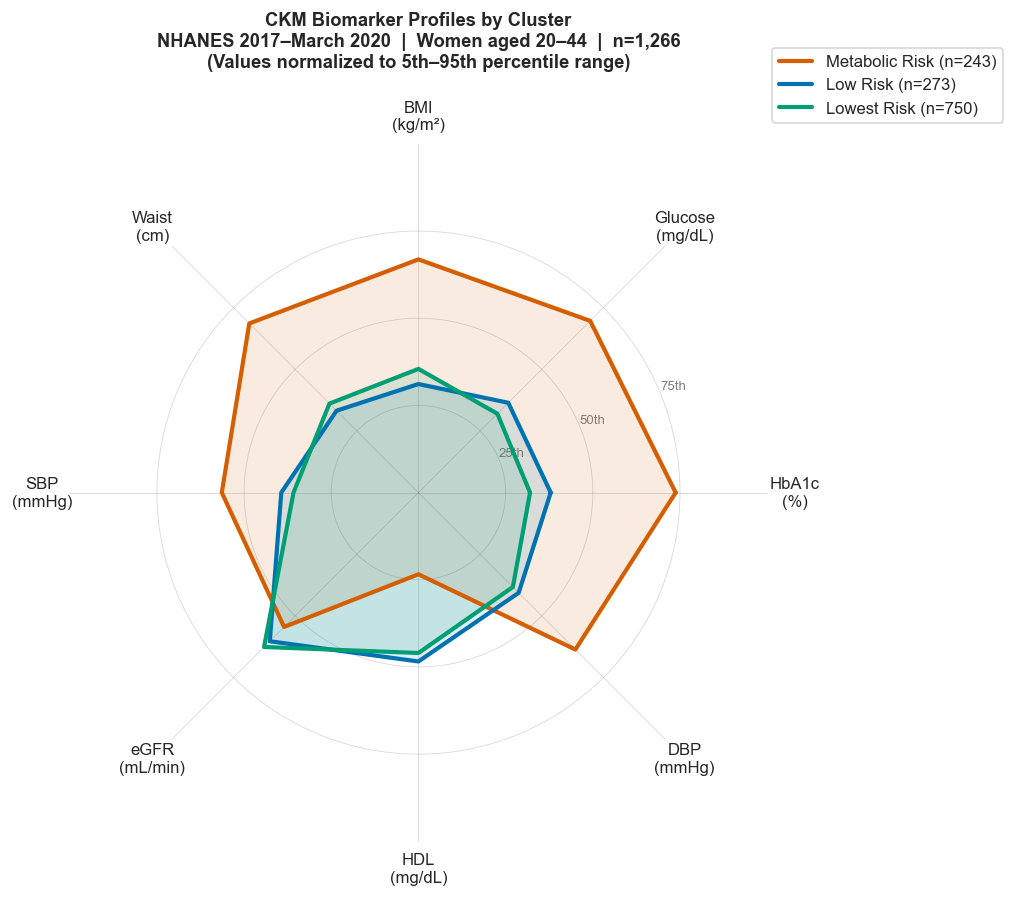

✓ Figure saved: cluster_radar_profiles.png


In [4]:
# ── Radar plot — cluster biomarker profiles ────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Features for radar — 8 CKM biomarkers in original units
radar_features = ['HbA1c_raw', 'Glucose_raw', 'BMI_raw', 'Waist_raw',
                  'Mean_SBP_raw', 'eGFR_raw', 'HDL_raw', 'Mean_DBP_raw']

radar_labels   = ['HbA1c\n(%)', 'Glucose\n(mg/dL)', 'BMI\n(kg/m²)',
                  'Waist\n(cm)', 'SBP\n(mmHg)', 'eGFR\n(mL/min)',
                  'HDL\n(mg/dL)', 'DBP\n(mmHg)']

# Normalize each feature to 0-1 range across the full sample
# for visual comparability
def normalize_for_radar(df, features):
    df_norm = df[features].copy()
    for feat in features:
        vals      = df[feat].dropna()
        feat_min  = vals.quantile(0.05)
        feat_max  = vals.quantile(0.95)
        df_norm[feat] = (df[feat] - feat_min) / (feat_max - feat_min)
        df_norm[feat] = df_norm[feat].clip(0, 1)
    return df_norm

df_norm = normalize_for_radar(df, radar_features)

# Compute cluster means on normalized features
cluster_means = {}
for c in [0, 1, 2]:
    mask = df['Cluster'] == c
    cluster_means[c] = df_norm.loc[mask, radar_features].mean().values

# ── Plot ───────────────────────────────────────────────────────────────────
N      = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(9, 9),
                        subplot_kw=dict(polar=True))

for c, label in CLUSTER_NAMES.items():
    values = cluster_means[c].tolist()
    values += values[:1]
    ax.plot(angles, values,
            color=CLUSTER_COLORS[c],
            linewidth=2.5,
            linestyle='solid',
            label=f'{label} (n={(df["Cluster"]==c).sum():,})')
    ax.fill(angles, values,
            color=CLUSTER_COLORS[c],
            alpha=0.12)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.50, 0.75])
ax.set_yticklabels(['25th', '50th', '75th'], fontsize=8, color='gray')
ax.grid(color='gray', alpha=0.3, linewidth=0.5)
ax.spines['polar'].set_visible(False)

ax.set_title(
    'CKM Biomarker Profiles by Cluster\n'
    'NHANES 2017–March 2020  |  Women aged 20–44  |  n=1,266\n'
    '(Values normalized to 5th–95th percentile range)',
    fontsize=11, fontweight='bold', pad=20
)

ax.legend(loc='upper right',
          bbox_to_anchor=(1.35, 1.15),
          fontsize=10,
          framealpha=0.9,
          edgecolor='lightgray')

plt.tight_layout()
plt.savefig(FIG_DIR / 'cluster_radar_profiles.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Figure saved: cluster_radar_profiles.png')

In [5]:
# ── APO enrichment analysis ────────────────────────────────────────────────
# Primary comparison: Metabolic Risk vs combined Low/Lowest Risk
# GDM history as the primary APO exposure

print('=== APO Enrichment Analysis ===\n')

# Define comparison groups
met_risk_mask = df['Cluster'] == 0
low_risk_mask = df['Cluster'].isin([1, 2])

# ── GDM history ────────────────────────────────────────────────────────────
gdm_col = 'Has_GDM_raw'

n_met     = met_risk_mask.sum()
n_low     = low_risk_mask.sum()
gdm_met   = df.loc[met_risk_mask, gdm_col].sum()
gdm_low   = df.loc[low_risk_mask, gdm_col].sum()
pct_met   = gdm_met / n_met * 100
pct_low   = gdm_low / n_low * 100

# Chi-square
ct_gdm    = pd.crosstab(df['Cluster'] == 0, df[gdm_col])
_, p_gdm, _, _ = chi2_contingency(ct_gdm)

# Odds ratio
or_gdm    = (gdm_met / (n_met - gdm_met)) / (gdm_low / (n_low - gdm_low))

print(f'GDM history:')
print(f'  Metabolic Risk:     {gdm_met:>3} / {n_met} ({pct_met:.1f}%)')
print(f'  Low + Lowest Risk:  {gdm_low:>3} / {n_low} ({pct_low:.1f}%)')
print(f'  Odds ratio:         {or_gdm:.2f}')
print(f'  Chi-square p-value: {fmt_p(p_gdm)}')

# ── Macrosomia history ─────────────────────────────────────────────────────
mac_col   = 'Has_Macrosomia_raw'
mac_met   = df.loc[met_risk_mask, mac_col].sum()
mac_low   = df.loc[low_risk_mask, mac_col].sum()
pct_mac_met = mac_met / n_met * 100
pct_mac_low = mac_low / n_low * 100

ct_mac    = pd.crosstab(df['Cluster'] == 0, df[mac_col])
_, p_mac, _, _ = chi2_contingency(ct_mac)
or_mac    = (mac_met / (n_met - mac_met)) / (mac_low / (n_low - mac_low))

print(f'\nMacrosomia history:')
print(f'  Metabolic Risk:     {mac_met:>3} / {n_met} ({pct_mac_met:.1f}%)')
print(f'  Low + Lowest Risk:  {mac_low:>3} / {n_low} ({pct_mac_low:.1f}%)')
print(f'  Odds ratio:         {or_mac:.2f}')
print(f'  Chi-square p-value: {fmt_p(p_mac)}')

# ── APO Score distribution ─────────────────────────────────────────────────
print(f'\nAPO Score distribution by cluster:')
print(f'  {"APO Score":<20} {"Met Risk":>10} {"Low Risk":>10} '
      f'{"Lowest Risk":>12} {"Total":>8}')
print(f'  {"─"*20} {"─"*10} {"─"*10} {"─"*12} {"─"*8}')

apo_labels_map = {
    0.0: 'No APOs',
    1.0: 'Macrosomia only',
    2.0: 'GDM only',
    3.0: 'GDM + Macrosomia',
}

# Never pregnant separately
never_counts = []
for c in [0, 1, 2]:
    mask  = df['Cluster'] == c
    never = (df.loc[mask, 'Ever_Pregnant'] == 0).sum()
    never_counts.append(never)

print(f'  {"Never pregnant":<20} '
      f'{never_counts[0]:>10} '
      f'{never_counts[1]:>10} '
      f'{never_counts[2]:>12} '
      f'{sum(never_counts):>8}')

for score, label in apo_labels_map.items():
    counts = []
    for c in [0, 1, 2]:
        mask = (df['Cluster'] == c) & \
               (df['Ever_Pregnant'] == 1) & \
               (df['APO_Score'] == score)
        counts.append(mask.sum())
    print(f'  {label:<20} '
          f'{counts[0]:>10} '
          f'{counts[1]:>10} '
          f'{counts[2]:>12} '
          f'{sum(counts):>8}')

print(f'  {"─"*20} {"─"*10} {"─"*10} {"─"*12} {"─"*8}')
print(f'  {"Total":<20} '
      f'{n_met:>10} '
      f'{(df["Cluster"]==1).sum():>10} '
      f'{(df["Cluster"]==2).sum():>12} '
      f'{len(df):>8}')

=== APO Enrichment Analysis ===

GDM history:
  Metabolic Risk:     38.0 / 243 (15.6%)
  Low + Lowest Risk:  72.0 / 1023 (7.0%)
  Odds ratio:         2.45
  Chi-square p-value: 0.001

Macrosomia history:
  Metabolic Risk:     39.0 / 243 (16.0%)
  Low + Lowest Risk:  77.0 / 1023 (7.5%)
  Odds ratio:         2.35
  Chi-square p-value: 0.002

APO Score distribution by cluster:
  APO Score              Met Risk   Low Risk  Lowest Risk    Total
  ──────────────────── ────────── ────────── ──────────── ────────
  Never pregnant               48         85          253      386
  No APOs                     128        135          413      676
  Macrosomia only              29         31           34       94
  GDM only                     28         17           43       88
  GDM + Macrosomia             10          5            7       22
  ──────────────────── ────────── ────────── ──────────── ────────
  Total                       243        273          750     1266


### The answer

Women with GDM history are 2.45 times more likely to be in the Metabolic 
Risk cluster than in the combined low-risk groups (15.6% vs 7.0%, 
OR=2.45, p=0.001). Macrosomia history shows nearly identical enrichment 
(16.0% vs 7.5%, OR=2.35, p=0.002). The radar plot makes the biomarker 
separation visually unambiguous — the orange polygon is dramatically 
larger across every metabolic dimension, dipping inward only at HDL 
where lower is worse.

This is not a subtle signal buried in noise. It is a consistent, 
multi-biomarker pattern that holds across HbA1c, glucose, BMI, waist 
circumference, blood pressure, and HDL simultaneously. A woman in the 
Metabolic Risk cluster at age 30 already looks metabolically different 
from her peers — and she is twice as likely to have had gestational 
diabetes.

**What this means — and what it doesn't**

The cross-sectional design is the central limitation here and it needs 
to be stated plainly. We cannot determine whether GDM caused the 
cardiometabolic dysregulation, whether pre-existing metabolic risk 
caused the GDM, or whether both reflect a shared underlying predisposition 
that was present before the pregnancy. The temporal relationship cannot 
be established from a single time point. This is documented in notebook 
01 as a structural data constraint — it is also a fundamental feature 
of the clinical question that has not been fully resolved even in 
prospective literature.

What the data does support: GDM history and early cardiometabolic 
dysregulation co-occur in reproductive-age women at rates that are 
not explained by chance. The Metabolic Risk cluster is not simply 
an "older and heavier" group — the medication prevalence table makes 
this clear. Metformin use is 7.4% versus 1.1%, antihypertensives 17.3% 
versus 4–5%. These women are already being treated. Their biomarker 
values — prediabetic HbA1c, impaired fasting glucose, low HDL — exist 
despite treatment, not in its absence.

**The two low-risk clusters**

The radar plot tells a secondary story: the Low Risk and Lowest Risk 
clusters are nearly indistinguishable visually. Their biomarker profiles 
overlap almost completely, and the bootstrap stability analysis in 
notebook 06 confirmed that the boundary between them is the least 
certain feature of the k=3 solution. They likely represent a continuous 
low-risk gradient rather than two discrete phenotypes. For clinical 
purposes, the meaningful distinction is between the Metabolic Risk 
cluster and everyone else — not between the two low-risk subgroups.

The one exception is age at menarche. The Low Risk cluster's median 
of 15.0 years versus 12.0 in the other two groups is an unexpected 
finding that the current analysis cannot fully explain. It may warrant 
follow-up in a dataset with longitudinal reproductive and metabolic 
data.

**The eGFR finding**

eGFR is essentially flat across all three clusters (110–115 mL/min). 
At ages 20–44 this is expected — glomerular filtration declines slowly 
and the kidney signal in CKM disease typically emerges in the fourth 
and fifth decades. The absence of eGFR differentiation is not a failure 
of the clustering — it is a clinically coherent finding that reflects 
the early-stage nature of the risk being phenotyped. If this cohort 
were followed for 20 years, the eGFR story would likely look very 
different.

**Bottom line**

The central clinical question has an answer: yes, women with adverse 
pregnancy outcomes already show distinct early cardiometabolic profiles 
at ages 20–44, concentrated in a phenotype defined by prediabetic 
glycemia, central obesity, elevated blood pressure, and low HDL. The 
GDM signal is present, statistically significant, and clinically 
plausible. The magnitude — roughly a doubling of odds — is meaningful 
without being dramatic, which is exactly what early-stage risk 
detection should look like. 

These are not sick women in the traditional sense — no single biomarker 
crosses a diagnostic threshold that triggers a clinic visit or a 
prescription. That is precisely the point. They sit in the space between 
normal and disease where the opportunity for intervention is greatest and 
the return on investment is highest.

Lifestyle modification, structured physical activity, dietary counseling, 
and targeted metabolic surveillance in this group — reproductive-age women 
with GDM history and early cardiometabolic dysregulation — represent the 
kind of preventive investment that cardiovascular medicine has historically 
underprioritized. The evidence base for primary prevention in this window 
is strong: reversing insulin resistance, reducing central adiposity, and 
lowering blood pressure before end-organ involvement occurs yields 
cardiovascular benefit that cannot be recovered by treating established 
disease a decade later.

GDM is already a recognized trigger for postpartum metabolic screening 
in clinical guidelines — but follow-through rates are poor and the 
screening window is narrow. What this analysis suggests is that the 
cardiometabolic signal persists well into the reproductive years, creating 
a longer and more accessible intervention window than the immediate 
postpartum period alone. A woman with GDM history at age 32 who lands 
in the Metabolic Risk cluster is not a cardiology patient yet. She is 
exactly the patient a well-designed preventive program should be 
reaching — and reaching now.

---
## Section 5 · Outlier Phenotype Characterization

Nineteen women were excluded from the primary clustering analysis in 
notebook 06 — not because they were unimportant, but because their 
extreme glucose dysregulation dominated k-selection metrics and obscured 
the structure of interest in the majority population. Exclusion from 
clustering is not exclusion from the story. These women represent the 
most severe end of the cardiometabolic risk spectrum in this sample and 
deserve careful characterization.

In [6]:
# ── Outlier phenotype characterization ────────────────────────────────────
# 19 women with extreme glucose dysregulation
# Compare to primary clusters using original-unit biomarkers from df_raw

print('=== Outlier Phenotype Characterization (n=19) ===\n')

# Get original-unit biomarkers for outliers from df_raw
df_out_raw = df_raw.loc[df_out.index].copy()

# ── Biomarker profile ──────────────────────────────────────────────────────
print(f'CKM Biomarkers — median [IQR]:')
print(f'  {"Feature":<25} {"Outlier (n=19)":>16} '
      f'{"Met Risk (n=243)":>18} {"Low Risk (n=273)":>18} '
      f'{"Lowest Risk (n=750)":>20}')
print(f'  {"─"*25} {"─"*16} {"─"*18} {"─"*18} {"─"*20}')

biomarkers = [
    ('HbA1c',    'HbA1c (%)'),
    ('Glucose',  'Glucose (mg/dL)'),
    ('BMI',      'BMI (kg/m²)'),
    ('Mean_SBP', 'Systolic BP (mmHg)'),
    ('eGFR',     'eGFR (mL/min)'),
    ('HDL',      'HDL (mg/dL)'),
]

def median_iqr(series):
    s = series.dropna()
    return f'{s.median():.1f} [{s.quantile(0.25):.1f}–{s.quantile(0.75):.1f}]'

for feat, label in biomarkers:
    out_val  = median_iqr(df_out_raw[feat]) if feat in df_out_raw else '—'
    c0_val   = median_iqr(df.loc[df['Cluster']==0, f'{feat}_raw'])
    c1_val   = median_iqr(df.loc[df['Cluster']==1, f'{feat}_raw'])
    c2_val   = median_iqr(df.loc[df['Cluster']==2, f'{feat}_raw'])
    print(f'  {label:<25} {out_val:>16} {c0_val:>18} {c1_val:>18} {c2_val:>20}')

# ── Reproductive history ───────────────────────────────────────────────────
print(f'\nReproductive history:')

ever_preg = (df_out_raw['Ever_Pregnant'] == 1).sum() \
    if 'Ever_Pregnant' in df_out_raw else \
    (df_out['Ever_Pregnant'] == 1).sum()

has_gdm   = df_out_raw['Has_GDM'].sum() \
    if 'Has_GDM' in df_out_raw else '—'

apo2      = (df_out_raw['APO_Score'] >= 2).sum() \
    if 'APO_Score' in df_out_raw else '—'

n_out = len(df_out)
print(f'  Ever pregnant:   {ever_preg} ({ever_preg/n_out*100:.0f}%)')
print(f'  GDM history:     {has_gdm} ({has_gdm/n_out*100:.0f}%)')
print(f'  APO≥2:           {apo2} ({apo2/n_out*100:.0f}%)')

# ── Age ────────────────────────────────────────────────────────────────────
age_out = df_out_raw['RIDAGEYR'] if 'RIDAGEYR' in df_out_raw.columns \
    else df_out['RIDAGEYR']
print(f'\nAge:')
print(f'  Median: {age_out.median():.0f} years '
      f'[{age_out.quantile(0.25):.0f}–{age_out.quantile(0.75):.0f}]')

# ── Medication prevalence ──────────────────────────────────────────────────
print(f'\nMedication prevalence:')
for med in ['On_Metformin', 'On_Insulin', 'On_Antihypertensive']:
    col = med
    src = df_out_raw if col in df_out_raw.columns else df_out
    n_med = src[col].sum() if col in src.columns else 0
    print(f'  {med:<30} {n_med} ({n_med/n_out*100:.0f}%)')

=== Outlier Phenotype Characterization (n=19) ===

CKM Biomarkers — median [IQR]:
  Feature                     Outlier (n=19)   Met Risk (n=243)   Low Risk (n=273)  Lowest Risk (n=750)
  ───────────────────────── ──────────────── ────────────────── ────────────────── ────────────────────
  HbA1c (%)                   9.4 [8.4–11.0]      5.8 [5.6–6.0]      5.3 [5.1–5.5]        5.2 [5.0–5.4]
  Glucose (mg/dL)           218.0 [198.0–280.0]  99.0 [92.0–107.0]   87.0 [82.0–91.0]     86.0 [81.0–91.0]
  BMI (kg/m²)               36.1 [34.0–40.0]   36.5 [31.6–43.1]   25.5 [21.6–31.0]     27.7 [22.9–32.9]
  Systolic BP (mmHg)        113.7 [105.0–124.2] 115.7 [106.2–127.8] 108.0 [101.0–115.7]  106.3 [100.0–113.6]
  eGFR (mL/min)             118.5 [111.3–125.3] 110.5 [97.7–117.4] 114.6 [100.5–120.6]  113.7 [101.4–121.6]
  HDL (mg/dL)               44.0 [38.5–56.0]   46.0 [39.0–52.0]   58.0 [49.0–68.0]     56.0 [48.0–66.0]

Reproductive history:
  Ever pregnant:   14 (74%)
  GDM history:     7.0 

### The outlier phenotype — nineteen women at the far end of the spectrum

The numbers are unambiguous. Median HbA1c of 9.4% and median fasting 
glucose of 218 mg/dL place every woman in this group well into the 
range of overt, poorly controlled diabetes — not prediabetes, not 
impaired fasting glucose, but frank hyperglycemia that has either gone 
unrecognized or proven resistant to treatment. The diagnostic thresholds 
for diabetes are HbA1c ≥6.5% and fasting glucose ≥126 mg/dL. These 
women exceed both by a wide margin.

What makes this group particularly striking is the medication profile. 
37% are on metformin, 32% on insulin, 32% on antihypertensives — and 
yet their HbA1c remains at 9.4%. Treatment is active and insufficient. 
This is not a group that has never been identified or never been treated. 
It is a group where the disease has outpaced the intervention.

**The GDM connection is the strongest signal in the entire dataset.**
37% of these 19 women have GDM history — more than double the Metabolic 
Risk cluster (15.6%) and more than five times the low-risk groups (7%). 
In a sample of 19 this cannot be over-interpreted statistically, but the 
direction is unambiguous and clinically coherent. GDM is not just a 
marker of future risk in this dataset — it appears at the far right tail 
of the metabolic risk distribution at rates that are difficult to dismiss.

**BMI tells an important secondary story.** At 36.1 kg/m², the outlier 
phenotype has nearly identical adiposity to the Metabolic Risk cluster 
(36.5 kg/m²). The difference between these two groups is not body size — 
it is the degree of glucose dysregulation. Two women with BMI 36 can 
have HbA1c of 5.8% or 9.4%. What separates them likely includes disease 
duration, genetic susceptibility, beta-cell reserve, and the timing and 
quality of intervention after GDM — none of which are measurable in this 
cross-sectional dataset.

**eGFR is preserved at 118.5 mL/min** — slightly above the other clusters 
and consistent with the hyperfiltration phase of early diabetic nephropathy, 
where glomerular pressure increases before filtration declines. Kidney 
function appears intact on the surface while the underlying architecture 
is under stress. This is a well-recognized early CKM pattern and a 
reminder that normal eGFR in the context of severe hyperglycemia is not 
reassurance — it is a window.

These 19 women are not an outlier curiosity. They are a preview. The 
Metabolic Risk cluster at median HbA1c 5.8% and the outlier phenotype 
at 9.4% share the same BMI, the same adiposity, and a similar GDM 
history — separated by time, disease progression, and the interventions 
that did or did not happen in between. That is not a statistical 
observation. It is a clinical argument for acting earlier.

---
## Section 6 · APO Unknown Group

89 ever-pregnant women could not be classified by APO status — they were 
asked about gestational diabetes and macrosomia but did not answer. They 
were excluded from clustering on principled grounds: APO_Score encodes 
discrete clinical events that cannot be statistically estimated. The 
sensitivity analysis in notebook 06 confirmed their exclusion did not 
materially alter the cluster structure (ARI=0.969). What remains is the 
descriptive question — are these women systematically different from the 
primary sample in ways that matter?

In [7]:
# ── APO unknown group characterization ────────────────────────────────────
print('=== APO Unknown Group Characterization (n=89) ===\n')

# Get biomarkers from df_raw for APO unknown women
df_apo_raw = df_raw.loc[df_apo_unk.index].copy()

# ── Biomarker comparison ───────────────────────────────────────────────────
print(f'CKM Biomarkers — median [IQR]:')
print(f'  {"Feature":<25} {"APO Unknown (n=89)":>20} '
      f'{"Primary Sample (n=1,266)":>26}')
print(f'  {"─"*25} {"─"*20} {"─"*26}')

for feat, label in biomarkers:
    if feat not in df_apo_raw.columns:
        continue
    apo_val     = median_iqr(df_apo_raw[feat])
    primary_val = median_iqr(df.loc[:, f'{feat}_raw'])
    print(f'  {label:<25} {apo_val:>20} {primary_val:>26}')

# ── Demographic comparison ─────────────────────────────────────────────────
print(f'\nDemographics:')
age_apo     = df_apo_raw['RIDAGEYR'] \
    if 'RIDAGEYR' in df_apo_raw.columns \
    else df_apo_unk['RIDAGEYR']
age_primary = df['RIDAGEYR']

print(f'  Age — APO unknown:      {median_iqr(age_apo)}')
print(f'  Age — Primary sample:   {median_iqr(age_primary)}')

# ── Pregnancy history ──────────────────────────────────────────────────────
print(f'\nPregnancy history (all are ever-pregnant by definition):')
for feat, label in [('Parity', 'Parity'),
                     ('Pregnancy_Loss', 'Pregnancy losses')]:
    if feat in df_apo_raw.columns:
        apo_val     = median_iqr(df_apo_raw[feat])
        primary_val = median_iqr(df[f'{feat}_raw'])
        print(f'  {label:<25} APO unknown: {apo_val}  |  '
              f'Primary: {primary_val}')

# ── Medication prevalence ──────────────────────────────────────────────────
print(f'\nMedication prevalence:')
print(f'  {"Medication":<30} {"APO Unknown":>12} {"Primary":>10}')
print(f'  {"─"*30} {"─"*12} {"─"*10}')

for med in MED_FLAGS:
    src_apo = df_apo_raw if med in df_apo_raw.columns \
        else df_apo_unk
    if med not in src_apo.columns:
        continue
    n_apo     = src_apo[med].sum()
    pct_apo   = n_apo / len(df_apo_unk) * 100
    n_primary = df[med].sum() if med in df.columns else 0
    pct_prim  = n_primary / len(df) * 100
    print(f'  {med:<30} '
          f'{n_apo:>5} ({pct_apo:>4.1f}%)  '
          f'{n_primary:>5} ({pct_prim:>4.1f}%)')

# ── Kruskal-Wallis comparison ──────────────────────────────────────────────
print(f'\nStatistical comparison (Mann-Whitney, APO unknown vs primary):')
print(f'  {"Feature":<25} {"p-value":>10}')
print(f'  {"─"*25} {"─"*10}')

for feat, label in biomarkers:
    if feat not in df_apo_raw.columns:
        continue
    apo_vals     = df_apo_raw[feat].dropna().values
    primary_vals = df[f'{feat}_raw'].dropna().values
    if len(apo_vals) < 5:
        continue
    _, p = mannwhitneyu(apo_vals, primary_vals, alternative='two-sided')
    print(f'  {label:<25} {fmt_p(p):>10}')

=== APO Unknown Group Characterization (n=89) ===

CKM Biomarkers — median [IQR]:
  Feature                     APO Unknown (n=89)   Primary Sample (n=1,266)
  ───────────────────────── ──────────────────── ──────────────────────────
  HbA1c (%)                        5.2 [5.0–5.5]              5.3 [5.1–5.5]
  Glucose (mg/dL)               86.0 [80.0–92.0]           88.0 [82.0–94.0]
  BMI (kg/m²)                   27.5 [23.4–34.1]           28.8 [23.6–34.7]
  Systolic BP (mmHg)         109.7 [102.7–116.0]        108.0 [101.0–116.7]
  eGFR (mL/min)               116.8 [99.1–124.1]        113.3 [100.5–120.8]
  HDL (mg/dL)                   58.0 [48.0–70.8]           54.0 [45.0–65.0]

Demographics:
  Age — APO unknown:      29.0 [25.0–34.0]
  Age — Primary sample:   32.0 [26.0–39.0]

Pregnancy history (all are ever-pregnant by definition):
  Parity                    APO unknown: 0.0 [0.0–0.0]  |  Primary: 2.0 [0.0–3.0]
  Pregnancy losses          APO unknown: 1.0 [1.0–2.0]  |  Primary: 0

### APO unknown — who are they and does their exclusion matter?

The biomarker comparison is reassuring. HbA1c, BMI, blood pressure, and 
eGFR are virtually indistinguishable between the APO unknown group and 
the primary sample — four of six comparisons are non-significant. Where 
differences exist, they favor lower risk: glucose is slightly lower 
(86 vs 88 mg/dL, p=0.033) and HDL is slightly higher (58 vs 54 mg/dL, 
p=0.027). If anything, excluding these women marginally understates the 
metabolic risk signal in the primary analysis rather than inflating it.

The pregnancy history is more revealing than the biomarkers. Median 
parity of 0.0 in the APO unknown group versus 2.0 in the primary 
sample — and median pregnancy losses of 1.0 versus 0.0. These are 
younger women (median 29 vs 32 years) who have been pregnant but whose 
pregnancies ended in loss rather than delivery. They could not answer 
the GDM and macrosomia questions not because they refused or didn't 
understand — but because their pregnancies never progressed to the 
gestational age where those complications are diagnosed or recorded.

This reframes the exclusion. These 89 women were not removed because 
of a data quality problem. They were removed because their reproductive 
history — predominantly pregnancy loss without delivery — meant that 
APO_Score could not be meaningfully assigned. Their cardiometabolic 
profiles are unremarkable relative to the primary sample, their 
exclusion did not alter the cluster structure (ARI=0.969), and the 
direction of their biomarker differences does not suggest hidden 
high-risk cases were systematically removed.

The one flag worth carrying forward: metformin use is 5.6% in this 
group versus 2.3% in the primary sample. With n=89 this is not a 
reliable estimate, but it is directionally consistent with a group 
that may have a higher-than-average prevalence of insulin resistance — 
itself associated with recurrent pregnancy loss. A larger dataset with 
complete APO ascertainment would be needed to explore this further.

In [8]:
# ── Stage 2 — fasting lipids by cluster ───────────────────────────────────
print('=== Stage 2 Analysis — Fasting Lipids ===\n')

# Fasting lipids from df_raw — available for subsample only
fasting_vars = ['Triglycerides', 'LDL', 'WTSAFPRP']

for var in fasting_vars:
    df[f'{var}_raw'] = df_raw.loc[df.index, var] \
        if var in df_raw.columns else np.nan

# ── Subsample size by cluster ──────────────────────────────────────────────
print('Fasting subsample availability by cluster:')
print(f'  {"Cluster":<20} {"Total":>8} {"Fasting":>10} {"% with data":>12}')
print(f'  {"─"*20} {"─"*8} {"─"*10} {"─"*12}')

for c, label in CLUSTER_NAMES.items():
    mask     = df['Cluster'] == c
    n_total  = mask.sum()
    n_fast   = df.loc[mask, 'Triglycerides_raw'].notna().sum()
    pct      = n_fast / n_total * 100
    print(f'  {label:<20} {n_total:>8,} {n_fast:>10,} {pct:>11.1f}%')

n_fasting_total = df['Triglycerides_raw'].notna().sum()
print(f'\n  Total with fasting lipids: {n_fasting_total:,} '
      f'({n_fasting_total/len(df)*100:.1f}% of clustering sample)')

# ── Triglycerides by cluster ───────────────────────────────────────────────
print(f'\nTriglycerides (mg/dL) — median [IQR]:')
print(f'  {"Cluster":<20} {"Median [IQR]":>20} {"N":>6}')
print(f'  {"─"*20} {"─"*20} {"─"*6}')

trig_groups = []
for c, label in CLUSTER_NAMES.items():
    mask = df['Cluster'] == c
    vals = df.loc[mask, 'Triglycerides_raw'].dropna()
    trig_groups.append(vals.values)
    print(f'  {label:<20} {median_iqr(vals):>20} {len(vals):>6,}')

_, p_trig = kruskal(*trig_groups)
print(f'  Kruskal-Wallis p: {fmt_p(p_trig)}')

# ── LDL by cluster ─────────────────────────────────────────────────────────
print(f'\nLDL cholesterol (mg/dL) — median [IQR]:')
print(f'  {"Cluster":<20} {"Median [IQR]":>20} {"N":>6}')
print(f'  {"─"*20} {"─"*20} {"─"*6}')

ldl_groups = []
for c, label in CLUSTER_NAMES.items():
    mask = df['Cluster'] == c
    vals = df.loc[mask, 'LDL_raw'].dropna()
    ldl_groups.append(vals.values)
    print(f'  {label:<20} {median_iqr(vals):>20} {len(vals):>6,}')

_, p_ldl = kruskal(*ldl_groups)
print(f'  Kruskal-Wallis p: {fmt_p(p_ldl)}')

# ── Clinical thresholds ────────────────────────────────────────────────────
print(f'\nClinical threshold analysis:')
for c, label in CLUSTER_NAMES.items():
    mask      = df['Cluster'] == c
    trig_vals = df.loc[mask, 'Triglycerides_raw'].dropna()
    ldl_vals  = df.loc[mask, 'LDL_raw'].dropna()

    high_trig = (trig_vals >= 150).sum()   # metabolic syndrome threshold
    high_ldl  = (ldl_vals >= 130).sum()    # borderline high

    print(f'\n  {label}:')
    print(f'    Triglycerides ≥150 mg/dL: '
          f'{high_trig} ({high_trig/len(trig_vals)*100:.1f}%)')
    print(f'    LDL ≥130 mg/dL:           '
          f'{high_ldl} ({high_ldl/len(ldl_vals)*100:.1f}%)')

=== Stage 2 Analysis — Fasting Lipids ===

Fasting subsample availability by cluster:
  Cluster                 Total    Fasting  % with data
  ──────────────────── ──────── ────────── ────────────
  Metabolic Risk            243        136        56.0%
  Low Risk                  273        143        52.4%
  Lowest Risk               750        347        46.3%

  Total with fasting lipids: 626 (49.4% of clustering sample)

Triglycerides (mg/dL) — median [IQR]:
  Cluster                      Median [IQR]      N
  ──────────────────── ──────────────────── ──────
  Metabolic Risk          93.0 [64.5–138.0]    136
  Low Risk                 61.0 [45.0–86.0]    143
  Lowest Risk              62.0 [47.0–94.0]    347
  Kruskal-Wallis p: <0.001

LDL cholesterol (mg/dL) — median [IQR]:
  Cluster                      Median [IQR]      N
  ──────────────────── ──────────────────── ──────
  Metabolic Risk         108.5 [88.8–124.0]    136
  Low Risk               100.0 [86.0–118.0]    145
  Low

### Fasting lipids confirm the metabolic syndrome pattern

626 women (49.4% of the clustering sample) have fasting lipid data, 
distributed across clusters at 56.0% (Metabolic Risk), 52.4% (Low Risk), 
and 46.3% (Lowest Risk). The slight differential — healthier women 
slightly less likely to have fasting data — means any participation bias 
would work against finding differences, making the results that follow 
conservative estimates.

**Triglycerides tell the clearest story.** Median 93 mg/dL in the 
Metabolic Risk cluster versus 61–62 mg/dL in the low-risk groups — 
50% higher, significant at p<0.001. More clinically meaningful: 22.1% 
of Metabolic Risk women exceed the metabolic syndrome threshold of 
150 mg/dL, compared to 2.8% in the Low Risk cluster and 8.1% in the 
Lowest Risk cluster. That eight-fold difference versus the Low Risk 
group is not a subtle finding.

**LDL is more modest but consistent** — 108.5 mg/dL versus 92–100 mg/dL, 
with 19.9% above 130 mg/dL in the Metabolic Risk cluster compared to 
12–14% elsewhere. LDL alone is not the primary lipid concern in 
metabolic syndrome — it is the combination that matters.

And that combination is now complete. The Metabolic Risk cluster shows 
elevated triglycerides, low HDL (46 mg/dL from the primary analysis), 
and modestly elevated LDL — the atherogenic lipid triad of insulin 
resistance. High triglycerides and low HDL together are a stronger 
cardiovascular risk signal than either alone, and both are present here 
in a cohort of women aged 20–44. This is not the lipid profile of a 
healthy young woman. It is the lipid profile of someone whose 
cardiovascular risk clock started earlier than her age suggests.

The fasting lipid analysis was conducted on approximately half the 
sample and used biomarkers the clustering algorithm never saw. That 
independence matters. A cluster solution can always be made to look 
meaningful if you evaluate it on the same data used to build it — 
the real test is whether it predicts something it had no access to. 
The Metabolic Risk cluster passes that test. Worse triglycerides, 
lower HDL, modestly higher LDL — consistently, significantly, in an 
independent biomarker set. 


---
## Section 8 · Clinical Implications

The findings from this analysis sit at the intersection of reproductive 
medicine and cardiovascular prevention — a space that has historically 
received less attention than either field deserves.

### What the data supports

Reproductive-age women with GDM history are overrepresented in a 
cardiometabolic risk cluster defined by prediabetic glycemia, central 
obesity, elevated blood pressure, low HDL, and elevated triglycerides. 
The enrichment is roughly 2.5-fold relative to women without APO history. 
The pattern is consistent across eight independent biomarkers, confirmed 
by fasting lipids the clustering algorithm never accessed, and present 
in women aged 20–44 — decades before cardiovascular events typically 
present.

The outlier phenotype adds an endpoint to that trajectory. Nineteen 
women sharing the same adiposity profile as the Metabolic Risk cluster 
but with median HbA1c of 9.4% and glucose of 218 mg/dL — 37% of whom 
have GDM history — represent what inadequately addressed cardiometabolic 
risk looks like at its most advanced expression in this age group.

### The intervention window

Current clinical guidelines recommend postpartum metabolic screening 
for women with GDM history — glucose testing at 4–12 weeks, then every 
1–3 years. Follow-through rates in practice are poor, and the framing 
is narrow: screen for diabetes, treat if found. What this analysis 
suggests is that the relevant risk window is substantially longer and 
the relevant target is broader than overt diabetes alone.

A woman with GDM history at age 30 who falls into the Metabolic Risk 
cluster has prediabetic glycemia, class II obesity, low HDL, and 
elevated triglycerides — none of which individually cross a treatment 
threshold, all of which together define a high-priority prevention 
target. She does not need a diabetes diagnosis to benefit from 
structured lifestyle intervention, nutritional counseling, and 
intensified cardiovascular surveillance. She needs to be identified 
and reached before the decade that separates her from the outlier 
phenotype closes.

The return on that investment is well-established in the primary 
prevention literature. The Diabetes Prevention Program demonstrated 
that intensive lifestyle modification reduces diabetes progression 
by 58% in high-risk individuals — a magnitude that pharmacotherapy 
alone does not match. Applied to women with GDM history and early 
cardiometabolic dysregulation, the potential impact extends beyond 
diabetes prevention to cardiovascular event reduction in a population 
that is young, potentially highly motivated, and has already had a 
clinical encounter — the GDM pregnancy — that could serve as the 
entry point.

### Limitations

Several constraints shape how far these conclusions can be pushed.

**Temporality.** The cross-sectional design cannot establish whether 
GDM preceded cardiometabolic dysregulation or whether both reflect 
shared underlying risk. The clinical literature supports a bidirectional 
relationship, but this dataset cannot adjudicate the direction.

**Hypertensive disorders of pregnancy.** Preeclampsia and gestational 
hypertension — which carry the strongest long-term cardiovascular risk 
signal of any pregnancy complication — are absent from the NHANES 
2017–March 2020 public use file. The APO_Score captures metabolic 
APOs only. The true GDM-independent cardiovascular risk signal from 
adverse pregnancy outcomes is likely larger than what is measurable 
here.

**Medication attenuation.** Women in the Metabolic Risk cluster carry 
substantially higher medication burdens — metformin at 7.4%, 
antihypertensives at 17.3%. Their biomarker values reflect treated 
disease. The underlying untreated risk burden is higher than the 
numbers suggest.

**Cluster boundary uncertainty.** The bootstrap stability analysis 
confirmed that the metabolic risk cluster is the stable feature of 
the k=3 solution, while the boundary between the two low-risk clusters 
is less certain. Individual-level cluster assignments should be 
interpreted with appropriate caution — the phenotypes are real at the 
group level, the boundaries are not sharp at the individual level.

**Generalizability.** NHANES is nationally representative but the 
analytical sample (n=1,266 after exclusions) is not large enough to 
support subgroup analyses by race/ethnicity or socioeconomic status 
with adequate precision. The cardiometabolic risk burden documented 
here likely varies substantially across demographic groups in ways 
this analysis cannot resolve.

### What this means for clinical practice

GDM should be understood not as a pregnancy complication that resolves 
at delivery but as a cardiometabolic stress test — one that identifies 
women whose underlying metabolic reserve was insufficient to meet the 
demands of pregnancy. The women who fail that stress test are not done 
with it at six weeks postpartum. They carry the result forward into 
their thirties and forties, accumulating risk that is measurable, 
addressable, and — critically — not yet irreversible.

The clinical infrastructure to reach these women exists. The obstetric 
encounter is one of the most consistent points of healthcare contact 
for reproductive-age women. A systematic handoff from obstetric care 
to preventive cardiology — built around GDM history as the entry 
criterion — would reach a high-yield population at exactly the moment 
when intervention has the greatest potential to alter the trajectory.

That handoff does not currently happen reliably. This analysis is one 
piece of the evidence base for why it should.